<a href="https://colab.research.google.com/github/ShreyaPatil789/IPCV_Lab/blob/main/Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image in grayscale
image = cv2.imread('imagedemo.jpg', cv2.IMREAD_GRAYSCALE)


In [10]:
# 1. Sobel Filter
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sobel_x, sobel_y)


In [11]:
# 2. Prewitt Filter
kernelx = np.array([[1,0,-1],[1,0,-1],[1,0,-1]])
kernely = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])
prewitt_x = cv2.filter2D(image, -1, kernelx)
prewitt_y = cv2.filter2D(image, -1, kernely)
prewitt = prewitt_x + prewitt_y


In [13]:
# 4. Laplacian
laplacian = cv2.Laplacian(image, cv2.CV_64F)


In [14]:
# 5. Laplacian of Gaussian (LoG)
blur = cv2.GaussianBlur(image, (3, 3), 0)
log = cv2.Laplacian(blur, cv2.CV_64F)

In [15]:
# 6. Canny Edge Detector
canny = cv2.Canny(image, 100, 200)

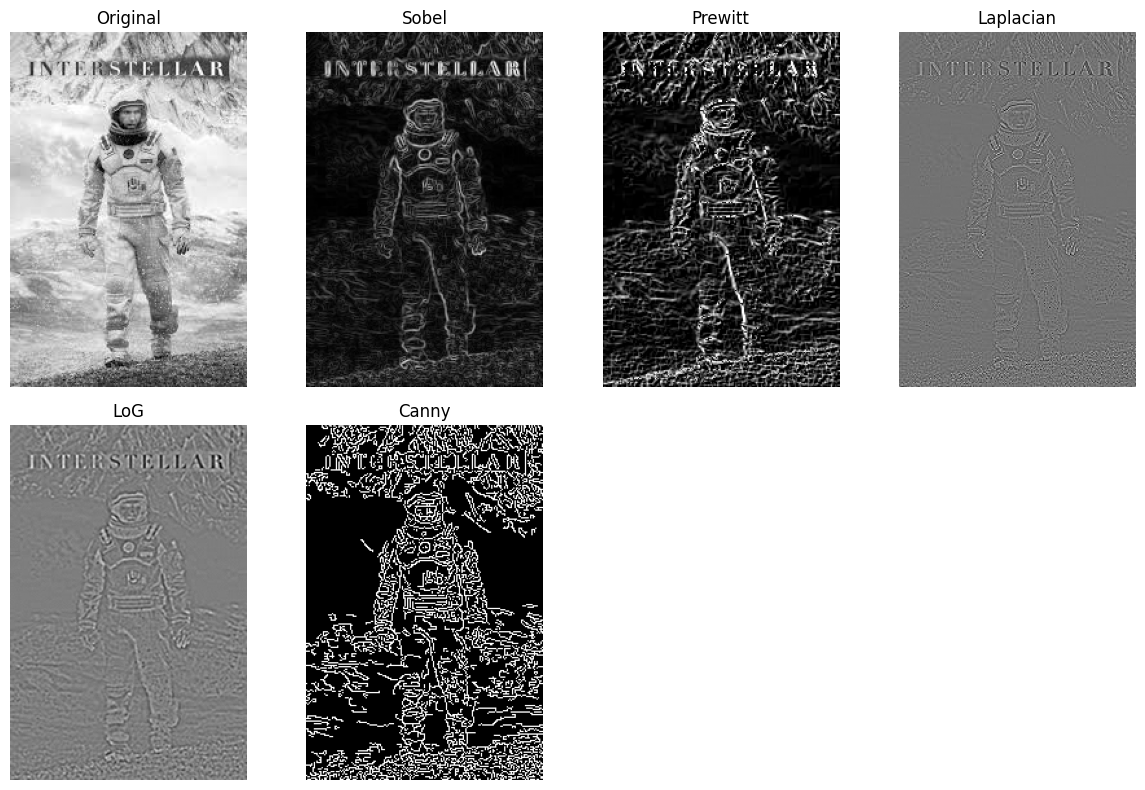

In [35]:
# Plot results
titles = ['Original', 'Sobel', 'Prewitt', 'Laplacian', 'LoG', 'Canny']
images = [image, sobel, prewitt,  laplacian, log, canny]

plt.figure(figsize=(12, 8))
for i in range(6):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()

plt.show()



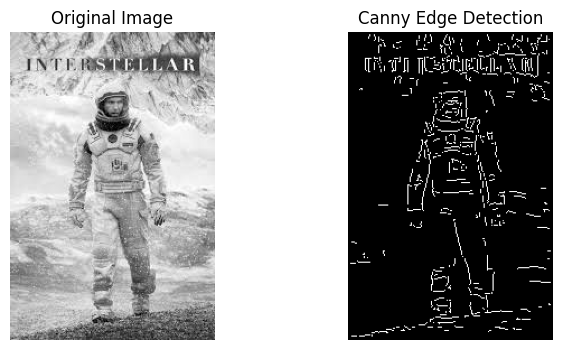

In [30]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


# ---- Step 1: Gaussian Blur (manual kernel) ----
def gaussian_kernel(size=5, sigma=1):
    ax = np.linspace(-(size // 2), size // 2, size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return kernel / np.sum(kernel)

def convolve(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape
    pad = kh // 2

    padded = np.pad(image, pad, mode='constant')
    output = np.zeros_like(image)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * kernel)

    return output

# ---- Step 2: Gradient (Sobel manually) ----
def sobel_filters(image):
    Kx = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
    Ky = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])

    Ix = convolve(image, Kx)
    Iy = convolve(image, Ky)

    G = np.hypot(Ix, Iy)
    G = G / G.max() * 255
    theta = np.arctan2(Iy, Ix)

    return G, theta

# ---- Step 3: Non-Maximum Suppression ----
def non_max_suppression(G, theta):
    h, w = G.shape
    Z = np.zeros((h, w), dtype=np.float32)

    angle = theta * 180. / np.pi
    angle[angle < 0] += 180

    for i in range(1, h-1):
        for j in range(1, w-1):
            q = 255
            r = 255

            # angle 0
            if (0 <= angle[i,j] < 22.5) or (157.5 <= angle[i,j] <= 180):
                q = G[i, j+1]
                r = G[i, j-1]
            # angle 45
            elif (22.5 <= angle[i,j] < 67.5):
                q = G[i+1, j-1]
                r = G[i-1, j+1]
            # angle 90
            elif (67.5 <= angle[i,j] < 112.5):
                q = G[i+1, j]
                r = G[i-1, j]
            # angle 135
            elif (112.5 <= angle[i,j] < 157.5):
                q = G[i-1, j-1]
                r = G[i+1, j+1]

            if (G[i,j] >= q) and (G[i,j] >= r):
                Z[i,j] = G[i,j]
            else:
                Z[i,j] = 0

    return Z

# ---- Step 4: Double Threshold ----
def threshold(image, low, high):
    strong = 255
    weak = 75

    res = np.zeros_like(image)

    strong_i, strong_j = np.where(image >= high)
    weak_i, weak_j = np.where((image >= low) & (image < high))

    res[strong_i, strong_j] = strong
    res[weak_i, weak_j] = weak

    return res, weak, strong

# ---- Step 5: Hysteresis ----
def hysteresis(image, weak, strong=255):
    h, w = image.shape

    for i in range(1, h-1):
        for j in range(1, w-1):
            if image[i,j] == weak:
                if np.any(image[i-1:i+2, j-1:j+2] == strong):
                    image[i,j] = strong
                else:
                    image[i,j] = 0
    return image

# ---- Main ----
img = cv2.imread('imagedemo.jpg', 0)

# Normalize
img = img.astype(np.float32)

# Step 1
kernel = gaussian_kernel(5, 1)
blurred = convolve(img, kernel)

# Step 2
gradient, theta = sobel_filters(blurred)

# Step 3
nms = non_max_suppression(gradient, theta)

# Step 4
thresh, weak, strong = threshold(nms, 20, 40)

# Step 5
edges = hysteresis(thresh, weak, strong)



plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title('Canny Edge Detection')
plt.axis('off')

plt.show()

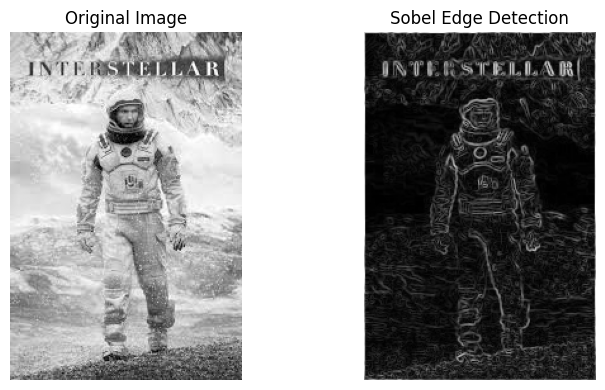

In [31]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ---- Convolution Function ----
def convolve(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape
    pad = kh // 2

    padded = np.pad(image, pad, mode='constant')
    output = np.zeros_like(image, dtype=np.float32)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * kernel)

    return output

# ---- Sobel Filter ----
def sobel_filter(image):
    Kx = np.array([[-1,0,1],
                   [-2,0,2],
                   [-1,0,1]])

    Ky = np.array([[-1,-2,-1],
                   [ 0, 0, 0],
                   [ 1, 2, 1]])

    Gx = convolve(image, Kx)
    Gy = convolve(image, Ky)

    G = np.sqrt(Gx**2 + Gy**2)
    G = (G / G.max()) * 255

    return G

# ---- Main ----
img = cv2.imread('imagedemo.jpg', 0)

if img is None:
    print("Error: Image not found!")
    exit()

img = img.astype(np.float32)

# Apply Sobel
edges = sobel_filter(img)

# ---- Display ONLY original + final ----
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title('Sobel Edge Detection')
plt.axis('off')

plt.tight_layout()
plt.show()

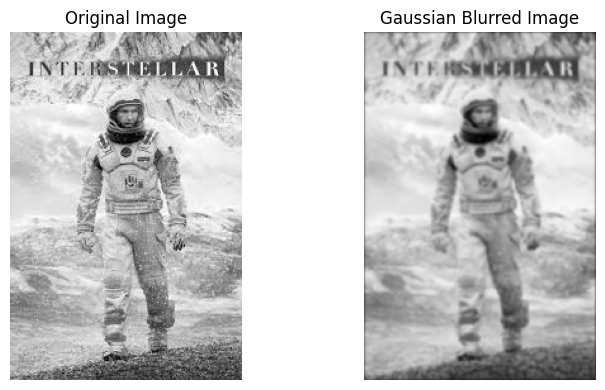

In [32]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ---- Gaussian Kernel ----
def gaussian_kernel(size=5, sigma=1):
    ax = np.linspace(-(size // 2), size // 2, size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return kernel / np.sum(kernel)

# ---- Convolution ----
def convolve(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape
    pad = kh // 2

    padded = np.pad(image, pad, mode='constant')
    output = np.zeros_like(image, dtype=np.float32)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * kernel)

    return output

# ---- Main ----
img = cv2.imread('imagedemo.jpg', 0)

if img is None:
    print("Error: Image not found!")
    exit()

img = img.astype(np.float32)

# Apply Gaussian filter
kernel = gaussian_kernel(size=5, sigma=1)
blurred = convolve(img, kernel)

# ---- Display ONLY original + blurred ----
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(blurred, cmap='gray')
plt.title('Gaussian Blurred Image')
plt.axis('off')

plt.tight_layout()
plt.show()

